# Eksperimen Sentence-BERT + Cosine Similarity + Fuzzy TOPSIS

Notebook ini memakai `Datasets/final_df.csv` sebagai eksperimen mandiri, tanpa koneksi ke Flask.

Fokus eksperimen:

1. Data understanding dan preprocessing dataset parfum.
2. Pembuatan representasi teks parfum untuk Sentence-BERT.
3. Fine-tuning Sentence-BERT memakai pseudo-label similarity dari atribut parfum.
4. Monitoring training loss dan validation loss.
5. Perhitungan cosine similarity antar embedding.
6. Ranking rekomendasi memakai Fuzzy TOPSIS.
7. Evaluasi retrieval, evaluasi validasi pair similarity, evaluasi skenario rekomendasi, dan visualisasi.

Catatan metodologi: dataset ini tidak punya label interaksi user seperti klik, pembelian, atau rating per user.
Karena itu training dan evaluasi memakai pseudo-label berbasis atribut parfum, misalnya family aroma,
notes, gender, character, concentration, dan kecocokan budget. Ini cocok untuk eksperimen SPK/ML,
tetapi bukan pengganti evaluasi dengan data user asli.

## 1. Dependency Check

In [34]:
import importlib.util
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "torch": "torch",
    "sentence_transformers": "sentence-transformers",
    "datasets": "datasets",
    "tqdm": "tqdm",
}

missing = [
    package_name
    for import_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing:
    print("Dependency belum lengkap:", ", ".join(missing))
    print("Jalankan dari root project:")
    print("python -m pip install -r requirements-experiment.txt")
    raise SystemExit("Install dependency eksperimen dulu, lalu run ulang notebook.")

import torch

print("Semua dependency eksperimen tersedia.")
print("torch:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("torch.cuda.is_available():", torch.cuda.is_available())

if not torch.cuda.is_available():
    print("")
    print("CUDA belum aktif di PyTorch.")
    print("Jika laptop/PC punya NVIDIA GPU, biasanya penyebabnya adalah PyTorch CPU-only.")
    print("Fix dari root project:")
    print("python -m pip uninstall -y torch torchvision torchaudio")
    print("python -m pip install -r requirements-experiment-cuda.txt")
    print("python -m pip install -r requirements-experiment.txt")

Semua dependency eksperimen tersedia.
torch: 2.11.0+cu128
torch.version.cuda: 12.8
torch.cuda.is_available(): True


## 2. Import Library dan Konfigurasi Eksperimen

In [35]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import json
import math
import random
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.0)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DATASET_PATH = PROJECT_ROOT / "Datasets" / "final_df.csv"
EXPERIMENT_DIR = PROJECT_ROOT / "reports" / "sbert_fuzzy_topsis"
ARTIFACT_DIR = PROJECT_ROOT / "models" / "sbert_fuzzy_topsis"

EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
FINE_TUNED_MODEL_DIR = ARTIFACT_DIR / "fine_tuned_model"
TRAINING_OUTPUT_DIR = ARTIFACT_DIR / "training_output"

RUN_TRAINING = True
EPOCHS = 10
BATCH_SIZE = 16
MAX_TRAIN_PAIRS = 12000
MAX_VAL_PAIRS = 2500
ENCODE_BATCH_SIZE = 64
RETRIEVAL_EVAL_QUERIES = 500
TOP_K_VALUES = [5, 10, 20]

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATASET_PATH)
print("CUDA tersedia:", torch.cuda.is_available())

Project root: f:\perkuliahan\Semester 6\SPK\project\parfum\Perfumes_Recommender-main
Dataset: f:\perkuliahan\Semester 6\SPK\project\parfum\Perfumes_Recommender-main\Datasets\final_df.csv
CUDA tersedia: True


## 3. Load Dataset dan Data Understanding

In [36]:
df_raw = pd.read_csv(DATASET_PATH)
print("Shape dataset mentah:", df_raw.shape)
display(df_raw.head())

Shape dataset mentah: (4239, 18)


,Name,Price,Description,Rate,Rating_count,image,Brand,Gender,Product_Type,Character_x,Fragrance_Family,Size,Year,Ingredients,Concentration,Top_note,Middle_note,Base_note
0,Dolce & Gabanna L'imperatrice 3 Pour Femme,199,Perfume for the energetic woman who is a hero in her movie in life every day! It keeps you vibrant and sparkling with irresistible attra...,5,6,https://assets.goldenscent.com/catalog/product/cache/1/image/9df78eab33525d08d6e5fb8d27136e95/3/4/3423473020615-dolce-_-gabbana-l_impera...,Dolce&Gabbana,Women,Perfume,Romantic,Floral,100 ml,2009,"watermerlon, kiwi, pink cyclamen, musk, pink pepper, jasmine, sandalwood, lemon tree",Eau de Toilette,"pink pepper, kiwi, rhubarb","jasmine, cyclamen, watermelon","musk, sandalwood, lemon trees."
1,Roberto Cavalli Paradiso,169,"Woody floral fragrance, a subtle aroma that makes you feel fresh with a stunning blend of citrus, jasmine, and cypress.",4.95,17,https://assets.goldenscent.com/catalog/product/cache/1/image/9df78eab33525d08d6e5fb8d27136e95/3/6/3607347733423c-roberto-cavalli-paradis...,Roberto Cavalli,Women,Perfume,Romantic,Woody,50 ml,2015,"citrus, mandarin, bergamot, jasmine, pine, cypress, laurel.",Eau de Parfum,"citruses , mandarin , bergamot",jasmine,"cypress, parasol pine, pink laurel"
2,Yves Saint Laurent Libre,389,"This perfume is a reflection of Freedom, specially designed for bold women, for those who live by their own rules, to enjoy the unique f...",5,3,https://assets.goldenscent.com/catalog/product/cache/1/image/9df78eab33525d08d6e5fb8d27136e95/3/6/3614272648418c-yves-saint-laurent-libr...,Yves Saint Laurent,Women,Perfume,Romantic,Floral,90 ml,2019,"mandarin orange, lavendar, black currant, petitgrain, jasmine, orange blossom, vanilla, cedar, musk, ambergris",Eau de Parfum,"mandarin orange, lavendar, black currant, petitgrain","jasmine, orange blossom","vanilla, cedar, musk, ambergris"
3,Mancera Red Tobacco,499,"Mancera Red Tobacco is the new oriental, woody fragrance for men and women. Its the best oriental scent, full of life and attractiveness...",4.38,8,https://assets.goldenscent.com/catalog/product/cache/1/image/9df78eab33525d08d6e5fb8d27136e95/3/6/3607347733423c-mancera-red-tobacco---1...,Mancera,Women,Perfume,Romantic,Oriental,120 ml,2017,"saffron, cinnamon, incense, nutmeg, white peach, green apple & nepalese oud, leaves of patchouli, delicate jasmine, precious tobacco, am...",Eau de Parfum,"saffron, cinnamon, incense, nutmeg, white peach, green apple, nepalese","patchouli, jasmine","tobacco, amber, woody notes, vetiver, vanilla, white musk"
4,Giorgio Armani Emporio Armani Stronger With You Intensely,399,"for every romantic gentle man, This strong fascinating fragrance is for you. It was released to capture all people hearts from the first...",5,3,https://assets.goldenscent.com/catalog/product/cache/1/image/9df78eab33525d08d6e5fb8d27136e95/3/6/3614272225718-giorgio-armani-emporio-a...,Giorgio Armani,Men,Perfume,Romantic,Aromatic,100 ml,2019,"spices, violet, lavender, sweet toffee, caramel, cinnamon, suede, vanilla, amber",Eau de Parfum,"pink pepper, juniper, violet leaf","lavender, sage, toffee, cinnamon","tonka bean, suede, amber, vanilla"


In [37]:
profile = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "unique": df_raw.nunique(dropna=True),
})
display(profile)

,dtype,missing,missing_pct,unique
Name,object,0,0.0,3525
Price,int64,0,0.0,876
Description,object,0,0.0,3566
Rate,object,0,0.0,22
Rating_count,object,0,0.0,13
image,object,0,0.0,3090
Brand,object,0,0.0,385
Gender,object,0,0.0,4
Product_Type,object,0,0.0,15
Character_x,object,0,0.0,12


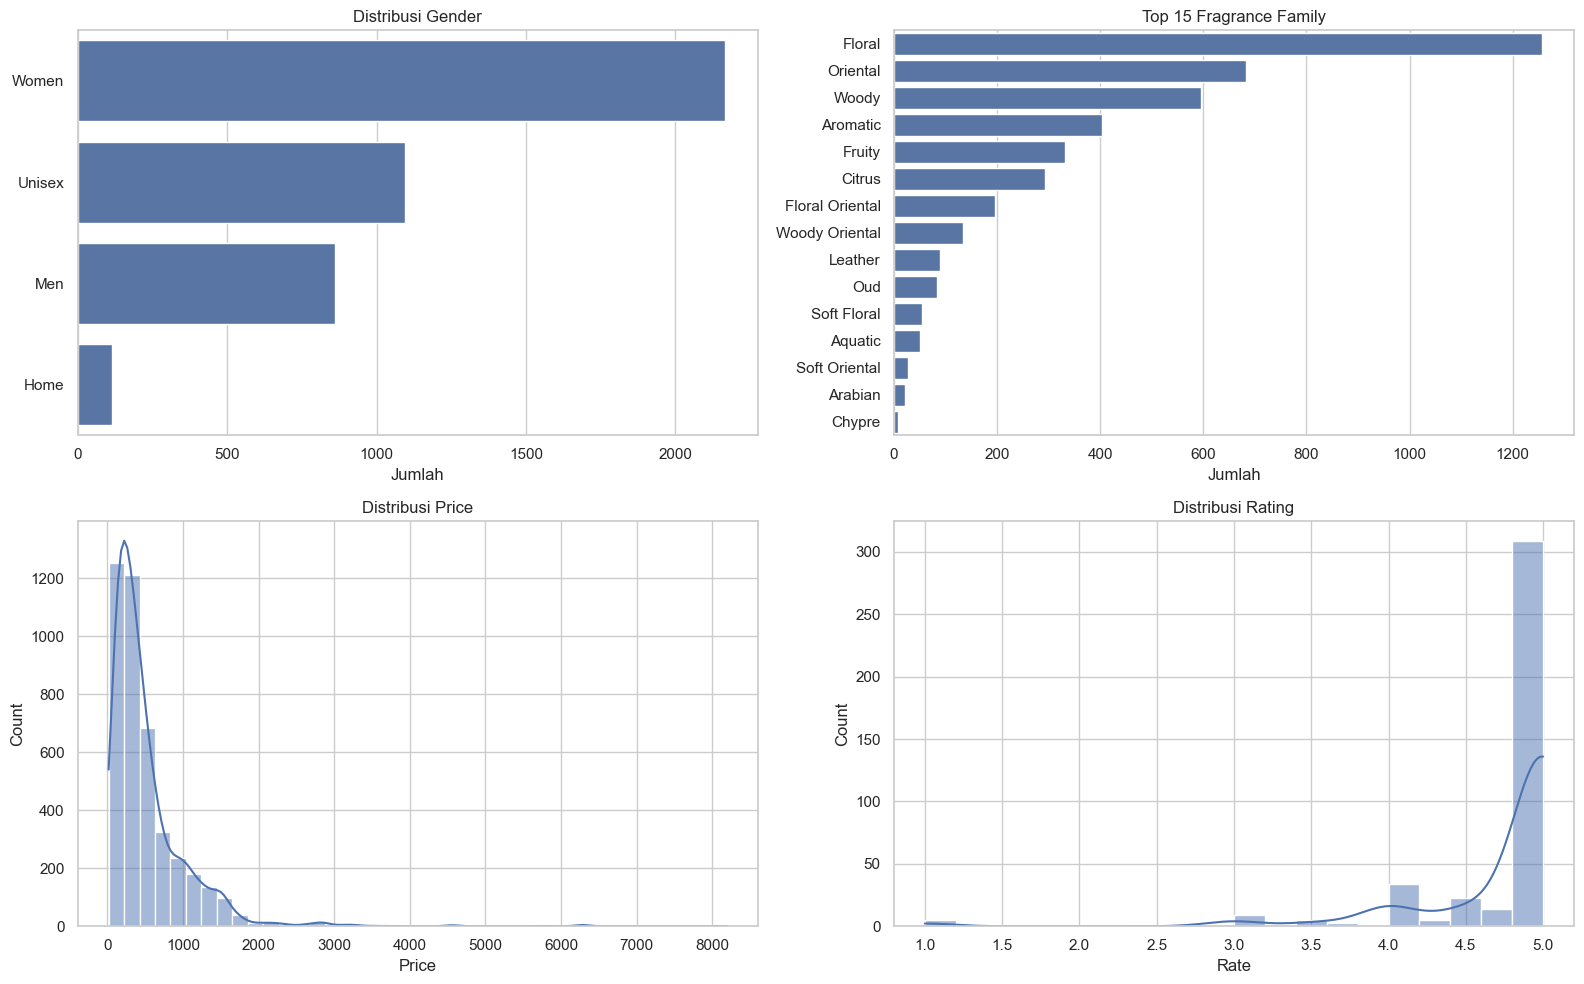

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=df_raw, y="Gender", order=df_raw["Gender"].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Distribusi Gender")
axes[0, 0].set_xlabel("Jumlah")
axes[0, 0].set_ylabel("")

top_family = df_raw["Fragrance_Family"].value_counts().head(15)
sns.barplot(x=top_family.values, y=top_family.index, ax=axes[0, 1])
axes[0, 1].set_title("Top 15 Fragrance Family")
axes[0, 1].set_xlabel("Jumlah")
axes[0, 1].set_ylabel("")

sns.histplot(df_raw["Price"], bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribusi Price")
axes[1, 0].set_xlabel("Price")

rate_numeric = pd.to_numeric(df_raw["Rate"], errors="coerce")
sns.histplot(rate_numeric.dropna(), bins=20, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Distribusi Rating")
axes[1, 1].set_xlabel("Rate")

plt.tight_layout()
plt.show()

## 4. Preprocessing Dataset

In [39]:
def clean_text(value) -> str:
    if value is None:
        return ""
    text = str(value).strip()
    if text.lower() in {"nan", "none", "null"}:
        return ""
    return re.sub(r"\s+", " ", text)


def normalize_text(value) -> str:
    text = clean_text(value).lower()
    text = re.sub(r"[^a-z0-9,\s&/\-]+", " ", text)
    text = re.sub(r"[_]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def parse_numeric(value, default=0.0) -> float:
    text = clean_text(value)
    if not text:
        return default
    try:
        return float(text.replace(",", "."))
    except ValueError:
        return default


def normalize_gender(value) -> str:
    text = normalize_text(value)
    if text in {"men", "man", "male", "pria", "laki laki"}:
        return "Men"
    if text in {"women", "woman", "female", "wanita", "perempuan"}:
        return "Women"
    if text in {"unisex", "all", "semua"}:
        return "Unisex"
    if text == "home":
        return "Home"
    return clean_text(value).title()


def split_terms(*values) -> set[str]:
    terms: set[str] = set()
    for value in values:
        text = normalize_text(value)
        if not text:
            continue
        for part in re.split(r"[,/&\-]+|\s+", text):
            part = part.strip()
            if len(part) >= 3:
                terms.add(part)
    return terms


def preprocess_perfume_data(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df.rename(columns={
        "Name": "name",
        "Price": "price",
        "Description": "description",
        "Rate": "rating",
        "Rating_count": "rating_count",
        "Brand": "brand",
        "Gender": "gender",
        "Product_Type": "product_type",
        "Character_x": "character",
        "Fragrance_Family": "fragrance_family",
        "Size": "size",
        "Year": "year",
        "Ingredients": "ingredients",
        "Concentration": "concentration",
        "Top_note": "top_note",
        "Middle_note": "middle_note",
        "Base_note": "base_note",
    }).copy()

    text_columns = [
        "name", "description", "image", "brand", "gender", "product_type",
        "character", "fragrance_family", "size", "ingredients",
        "concentration", "top_note", "middle_note", "base_note",
    ]
    for column in text_columns:
        if column not in df.columns:
            df[column] = ""
        df[column] = df[column].map(clean_text)

    df["price"] = pd.to_numeric(df.get("price", 0), errors="coerce").fillna(0.0)
    df["rating"] = pd.to_numeric(df.get("rating", 0), errors="coerce").fillna(0.0)
    df["rating_count"] = pd.to_numeric(df.get("rating_count", 0), errors="coerce").fillna(0).astype(int)
    df["year"] = pd.to_numeric(df.get("year", 0), errors="coerce").fillna(0).astype(int)
    df["gender"] = df["gender"].map(normalize_gender)

    product_mask = df["product_type"].str.contains("perfume", case=False, na=False)
    gender_mask = df["gender"].ne("Home")
    df = df[product_mask & gender_mask].copy()

    df = df.drop_duplicates(subset=["name", "brand", "size"], keep="first")
    df = df.reset_index(drop=True)
    df["perfume_id"] = df.index

    df["fragrance_family"] = df["fragrance_family"].str.replace(r"\s+", " ", regex=True).str.strip()
    df["fragrance_family_norm"] = df["fragrance_family"].map(normalize_text)
    df["character_norm"] = df["character"].map(normalize_text)
    df["concentration_norm"] = df["concentration"].map(normalize_text)

    df["note_terms"] = df.apply(
        lambda row: split_terms(
            row["fragrance_family"],
            row["character"],
            row["top_note"],
            row["middle_note"],
            row["base_note"],
            row["ingredients"],
        ),
        axis=1,
    )

    df["semantic_text"] = df.apply(build_semantic_text, axis=1)
    return df


def build_semantic_text(row: pd.Series) -> str:
    parts = [
        f"Perfume name: {clean_text(row.get('name'))}",
        f"Brand: {clean_text(row.get('brand'))}",
        f"Gender: {clean_text(row.get('gender'))}",
        f"Fragrance family: {clean_text(row.get('fragrance_family'))}",
        f"Character: {clean_text(row.get('character'))}",
        f"Concentration: {clean_text(row.get('concentration'))}",
        f"Top notes: {clean_text(row.get('top_note'))}",
        f"Middle notes: {clean_text(row.get('middle_note'))}",
        f"Base notes: {clean_text(row.get('base_note'))}",
        f"Ingredients: {clean_text(row.get('ingredients'))}",
        f"Description: {clean_text(row.get('description'))}",
    ]
    return ". ".join(part for part in parts if part.split(":", 1)[-1].strip())

In [40]:
df = preprocess_perfume_data(df_raw)
print("Shape setelah preprocessing:", df.shape)
display(df[[
    "perfume_id", "name", "brand", "gender", "price", "rating",
    "rating_count", "fragrance_family", "character", "top_note",
    "middle_note", "base_note", "semantic_text",
]].head())

Shape setelah preprocessing: (3296, 24)


,perfume_id,name,brand,gender,price,rating,rating_count,fragrance_family,character,top_note,middle_note,base_note,semantic_text
0,0,Dolce & Gabanna L'imperatrice 3 Pour Femme,Dolce&Gabbana,Women,199,5.00,6,Floral,Romantic,"pink pepper, kiwi, rhubarb","jasmine, cyclamen, watermelon","musk, sandalwood, lemon trees.",Perfume name: Dolce & Gabanna L'imperatrice 3 Pour Femme. Brand: Dolce&Gabbana. Gender: Women. Fragrance family: Floral. Character: Roma...
1,1,Roberto Cavalli Paradiso,Roberto Cavalli,Women,169,4.95,17,Woody,Romantic,"citruses , mandarin , bergamot",jasmine,"cypress, parasol pine, pink laurel",Perfume name: Roberto Cavalli Paradiso. Brand: Roberto Cavalli. Gender: Women. Fragrance family: Woody. Character: Romantic. Concentrati...
2,2,Yves Saint Laurent Libre,Yves Saint Laurent,Women,389,5.00,3,Floral,Romantic,"mandarin orange, lavendar, black currant, petitgrain","jasmine, orange blossom","vanilla, cedar, musk, ambergris",Perfume name: Yves Saint Laurent Libre. Brand: Yves Saint Laurent. Gender: Women. Fragrance family: Floral. Character: Romantic. Concent...
3,3,Mancera Red Tobacco,Mancera,Women,499,4.38,8,Oriental,Romantic,"saffron, cinnamon, incense, nutmeg, white peach, green apple, nepalese","patchouli, jasmine","tobacco, amber, woody notes, vetiver, vanilla, white musk",Perfume name: Mancera Red Tobacco. Brand: Mancera. Gender: Women. Fragrance family: Oriental. Character: Romantic. Concentration: Eau de...
4,4,Giorgio Armani Emporio Armani Stronger With You Intensely,Giorgio Armani,Men,399,5.00,3,Aromatic,Romantic,"pink pepper, juniper, violet leaf","lavender, sage, toffee, cinnamon","tonka bean, suede, amber, vanilla",Perfume name: Giorgio Armani Emporio Armani Stronger With You Intensely. Brand: Giorgio Armani. Gender: Men. Fragrance family: Aromatic....


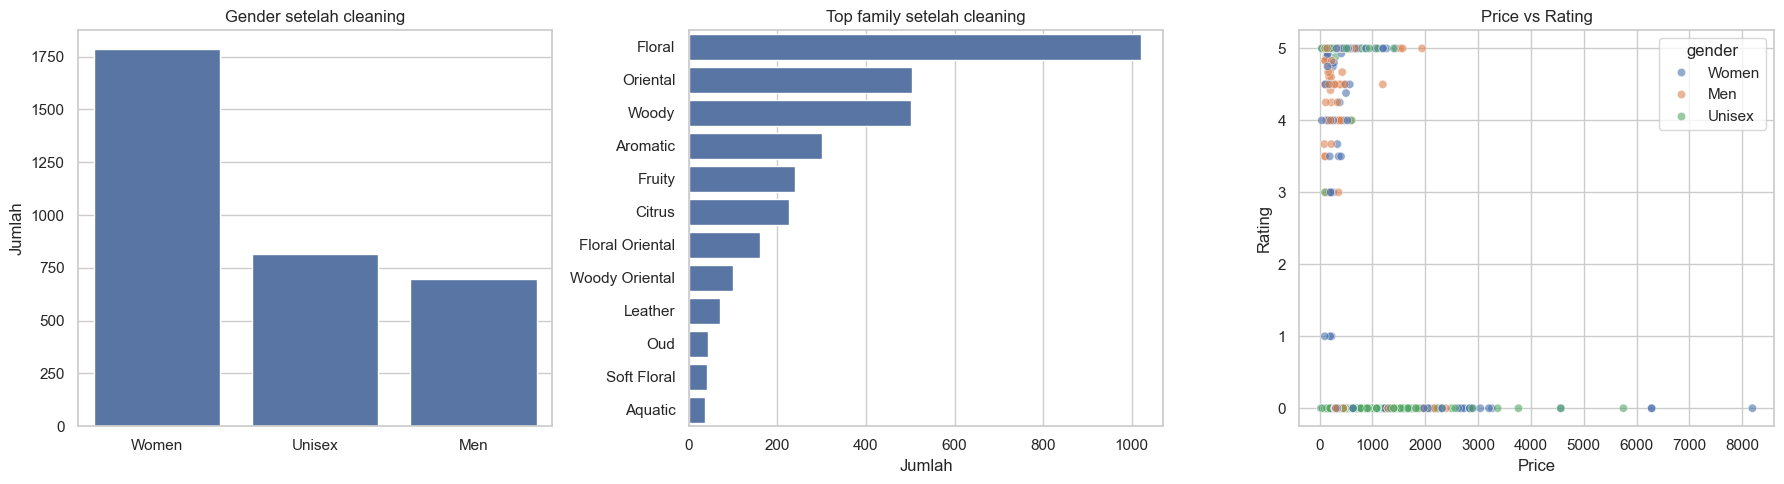

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="gender", order=df["gender"].value_counts().index, ax=axes[0])
axes[0].set_title("Gender setelah cleaning")
axes[0].set_xlabel("")
axes[0].set_ylabel("Jumlah")

family_clean = df["fragrance_family"].value_counts().head(12)
sns.barplot(x=family_clean.values, y=family_clean.index, ax=axes[1])
axes[1].set_title("Top family setelah cleaning")
axes[1].set_xlabel("Jumlah")
axes[1].set_ylabel("")

sns.scatterplot(data=df, x="price", y="rating", hue="gender", alpha=0.6, ax=axes[2])
axes[2].set_title("Price vs Rating")
axes[2].set_xlabel("Price")
axes[2].set_ylabel("Rating")

plt.tight_layout()
plt.show()

## 5. Pseudo-Label Pair untuk Fine-Tuning Sentence-BERT

Karena tidak ada label similarity manual, notebook ini membuat pseudo-label:

- Pasangan positif: parfum dari fragrance family yang sama atau punya overlap notes yang kuat.
- Pasangan negatif: fragrance family berbeda dan overlap notes rendah.
- Score 0 sampai 1 dihitung dari family, note overlap, gender, character, dan concentration.

Pseudo-label ini dipakai untuk fine-tuning SBERT dengan `CosineSimilarityLoss`.

In [42]:
RELATED_FAMILY_GROUPS = [
    {"fresh", "citrus", "aquatic", "green", "fruity"},
    {"floral", "soft floral", "fruity", "sweet", "romantic"},
    {"woody", "aromatic", "spicy", "oud", "leather"},
    {"oriental", "amber", "musk", "arabian", "soft oriental", "oud"},
    {"sweet", "vanilla", "gourmand", "fruity", "caramel"},
]


def note_jaccard(left: set[str], right: set[str]) -> float:
    if not left or not right:
        return 0.0
    union = left | right
    if not union:
        return 0.0
    return len(left & right) / len(union)


def related_family_score(left_family: str, right_family: str) -> float:
    left = normalize_text(left_family)
    right = normalize_text(right_family)
    if not left or not right:
        return 0.3
    if left == right:
        return 1.0
    left_terms = split_terms(left)
    right_terms = split_terms(right)
    if left_terms & right_terms:
        return 0.8
    for group in RELATED_FAMILY_GROUPS:
        if (left in group or left_terms & group) and (right in group or right_terms & group):
            return 0.65
    return 0.15


def gender_pair_score(left_gender: str, right_gender: str) -> float:
    left = normalize_gender(left_gender)
    right = normalize_gender(right_gender)
    if left == right:
        return 1.0
    if "Unisex" in {left, right}:
        return 0.75
    return 0.2


def pair_similarity_score(left: pd.Series, right: pd.Series) -> float:
    family = related_family_score(left["fragrance_family"], right["fragrance_family"])
    notes = note_jaccard(left["note_terms"], right["note_terms"])
    gender = gender_pair_score(left["gender"], right["gender"])
    character = 1.0 if left["character_norm"] and left["character_norm"] == right["character_norm"] else 0.25
    concentration = 1.0 if left["concentration_norm"] and left["concentration_norm"] == right["concentration_norm"] else 0.35

    score = (
        0.45 * family
        + 0.30 * notes
        + 0.10 * gender
        + 0.10 * character
        + 0.05 * concentration
    )
    return float(np.clip(score, 0.0, 1.0))


def generate_similarity_pairs(data: pd.DataFrame, max_pairs: int, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = len(data)
    family_to_indices = data.groupby("fragrance_family_norm").indices
    valid_family_groups = [np.array(indices) for indices in family_to_indices.values() if len(indices) >= 2]

    pairs = []
    seen: set[tuple[int, int]] = set()

    def add_pair(i: int, j: int, label_type: str) -> bool:
        if i == j:
            return False
        key = tuple(sorted((int(i), int(j))))
        if key in seen:
            return False
        seen.add(key)

        left = data.iloc[i]
        right = data.iloc[j]
        score = pair_similarity_score(left, right)
        if label_type == "positive":
            score = max(score, 0.65)
        elif label_type == "negative":
            score = min(score, 0.35)

        pairs.append({
            "idx1": int(i),
            "idx2": int(j),
            "sentence1": left["semantic_text"],
            "sentence2": right["semantic_text"],
            "score": round(float(score), 4),
            "pair_type": label_type,
            "family1": left["fragrance_family"],
            "family2": right["fragrance_family"],
        })
        return True

    target_positive = max_pairs // 2
    attempts = 0
    while len([p for p in pairs if p["pair_type"] == "positive"]) < target_positive and attempts < max_pairs * 40:
        attempts += 1
        group = valid_family_groups[rng.integers(0, len(valid_family_groups))]
        i, j = rng.choice(group, size=2, replace=False)
        add_pair(int(i), int(j), "positive")

    target_total = max_pairs
    attempts = 0
    while len(pairs) < target_total and attempts < max_pairs * 80:
        attempts += 1
        i, j = rng.choice(n, size=2, replace=False)
        if data.iloc[i]["fragrance_family_norm"] == data.iloc[j]["fragrance_family_norm"]:
            continue
        add_pair(int(i), int(j), "negative")

    return pd.DataFrame(pairs).sample(frac=1, random_state=seed).reset_index(drop=True)


pairs_df = generate_similarity_pairs(df, max_pairs=MAX_TRAIN_PAIRS + MAX_VAL_PAIRS, seed=SEED)
print("Jumlah pair:", len(pairs_df))
display(pairs_df.head())
display(pairs_df["pair_type"].value_counts())

Jumlah pair: 14500


,idx1,idx2,sentence1,sentence2,score,pair_type,family1,family2
0,593,1374,Perfume name: Lancome Poeme. Brand: Lancome. Gender: Women. Fragrance family: Oriental. Character: Romantic. Concentration: Eau de Parfu...,Perfume name: Costume National Homme Parfum EDP. Brand: Costume National. Gender: Men. Fragrance family: Woody Oriental. Character: Glam...,0.3500,negative,Oriental,Woody Oriental
1,550,1247,Perfume name: Boucheron Oud De Carthage. Brand: Boucheron. Gender: Unisex. Fragrance family: Leather. Character: Charismatic. Concentrat...,Perfume name: Atelier Cologne Camelia Intrepide. Brand: Atelier Cologne. Gender: Women. Fragrance family: Leather. Character: Romantic. ...,0.6500,positive,Leather,Leather
2,1225,1730,Perfume name: Versace The Dreamer. Brand: Versace. Gender: Men. Fragrance family: Oriental. Character: Romantic. Concentration: Eau de T...,Perfume name: Guerlain La Petite Robe Noire Velours EDP. Brand: Guerlain. Gender: Women. Fragrance family: Floral. Character: Romantic. ...,0.2770,negative,Oriental,Floral
3,595,2963,Perfume name: Paris Hilton Gold Rush. Brand: Paris Hilton. Gender: Women. Fragrance family: Floral. Character: Glamorous. Concentration:...,Perfume name: Exuma Parfums World Eternal Ice EDP. Brand: Exuma Parfums. Gender: Unisex. Fragrance family: Woody. Character: Natural. Co...,0.2369,negative,Floral,Woody
4,94,1138,Perfume name: Van Cleef & Arpels Precious Oud Collection Extraordinaire. Brand: Van Cleef & Arpels. Gender: Unisex. Fragrance family: Wo...,Perfume name: Mood By Minis Amber Mood EDP. Brand: Minis. Gender: Unisex. Fragrance family: Woody. Character: Romantic. Concentration: E...,0.6500,positive,Woody,Woody


pair_type
negative    7250
positive    7250
Name: count, dtype: int64

In [43]:
bins = pd.cut(pairs_df["score"], bins=[-0.01, 0.35, 0.65, 1.0], labels=["low", "medium", "high"])

try:
    train_pairs, val_pairs = train_test_split(
        pairs_df,
        test_size=MAX_VAL_PAIRS,
        random_state=SEED,
        stratify=bins,
    )
except ValueError:
    train_pairs, val_pairs = train_test_split(
        pairs_df,
        test_size=MAX_VAL_PAIRS,
        random_state=SEED,
    )

train_pairs = train_pairs.head(MAX_TRAIN_PAIRS).reset_index(drop=True)
val_pairs = val_pairs.head(MAX_VAL_PAIRS).reset_index(drop=True)

print("Train pairs:", train_pairs.shape)
print("Validation pairs:", val_pairs.shape)
display(pd.DataFrame({
    "train_score": train_pairs["score"].describe(),
    "val_score": val_pairs["score"].describe(),
}))

Train pairs: (12000, 8)
Validation pairs: (2500, 8)


,train_score,val_score
count,12000.000000,2500.000000
mean,0.473392,0.474159
std,0.215272,0.214557
min,0.130000,0.130000
25%,0.252500,0.252800
50%,0.500000,0.500000
75%,0.650000,0.650000
max,1.000000,1.000000


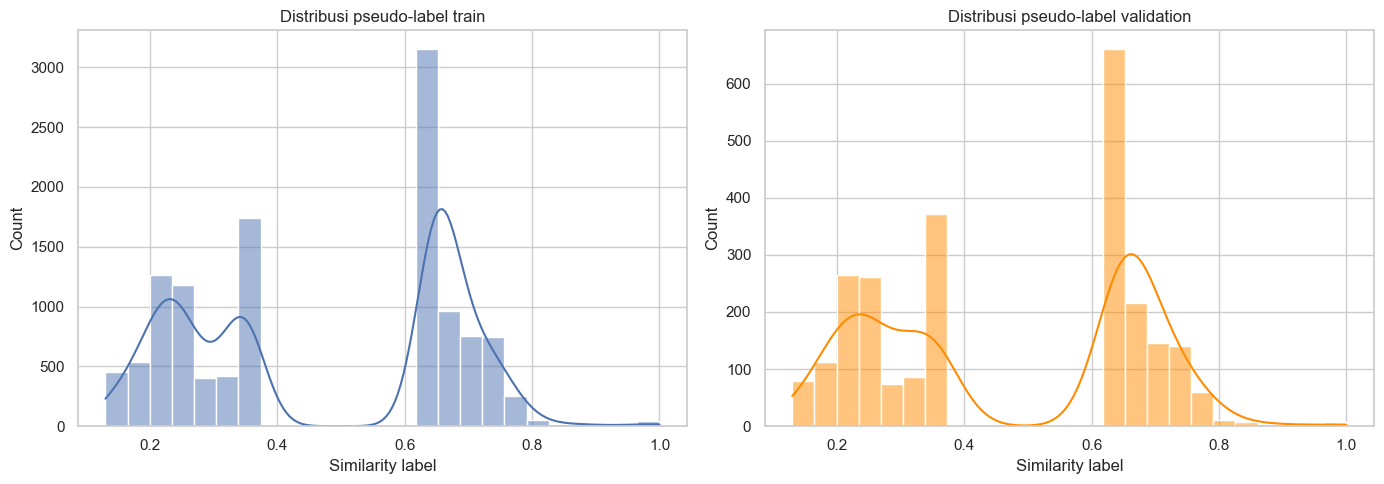

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_pairs["score"], bins=25, kde=True, ax=axes[0])
axes[0].set_title("Distribusi pseudo-label train")
axes[0].set_xlabel("Similarity label")

sns.histplot(val_pairs["score"], bins=25, kde=True, color="darkorange", ax=axes[1])
axes[1].set_title("Distribusi pseudo-label validation")
axes[1].set_xlabel("Similarity label")

plt.tight_layout()
plt.show()

## 6. Training Sentence-BERT dan Monitoring Loss

In [45]:
from datasets import Dataset
from sentence_transformers import SentenceTransformer, SentenceTransformerTrainer, SentenceTransformerTrainingArguments, losses

try:
    from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
except ImportError:
    from sentence_transformers.sentence_transformer.evaluation import EmbeddingSimilarityEvaluator


def build_training_args() -> SentenceTransformerTrainingArguments:
    common = dict(
        output_dir=str(TRAINING_OUTPUT_DIR),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=2e-5,
        warmup_ratio=0.10,
        logging_steps=25,
        eval_steps=100,
        save_strategy="epoch",
        save_total_limit=2,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )
    try:
        return SentenceTransformerTrainingArguments(eval_strategy="steps", **common)
    except TypeError:
        return SentenceTransformerTrainingArguments(evaluation_strategy="steps", **common)


train_dataset = Dataset.from_pandas(
    train_pairs[["sentence1", "sentence2", "score"]],
    preserve_index=False,
)
val_dataset = Dataset.from_pandas(
    val_pairs[["sentence1", "sentence2", "score"]],
    preserve_index=False,
)

training_history_path = EXPERIMENT_DIR / "training_history.csv"

if RUN_TRAINING:
    sbert_model = SentenceTransformer(BASE_MODEL_NAME)
    train_loss = losses.CosineSimilarityLoss(sbert_model)

    evaluator = EmbeddingSimilarityEvaluator(
        sentences1=val_pairs["sentence1"].tolist(),
        sentences2=val_pairs["sentence2"].tolist(),
        scores=val_pairs["score"].tolist(),
        name="perfume_similarity_val",
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        write_csv=True,
    )

    args = build_training_args()
    trainer = SentenceTransformerTrainer(
        model=sbert_model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        loss=train_loss,
        evaluator=evaluator,
    )

    train_result = trainer.train()
    sbert_model.save(str(FINE_TUNED_MODEL_DIR))

    history_df = pd.DataFrame(trainer.state.log_history)
    history_df.to_csv(training_history_path, index=False)
    trainer.state.save_to_json(str(EXPERIMENT_DIR / "trainer_state.json"))

    print("Model fine-tuned disimpan ke:", FINE_TUNED_MODEL_DIR)
    print("Training metrics:", train_result.metrics)
else:
    if training_history_path.exists():
        history_df = pd.read_csv(training_history_path)
    else:
        history_df = pd.DataFrame()
    print("RUN_TRAINING=False, memakai model yang sudah ada atau base model.")

display(history_df.tail(10))

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Perfume Similarity Val Pearson Cosine,Perfume Similarity Val Spearman Cosine
100,0.049300,0.046796,0.192970,0.182587
200,0.032700,0.021957,0.791521,0.816273
300,0.006000,0.011877,0.952249,0.922155
400,0.006000,0.014882,0.957895,0.935389
500,0.005400,0.011150,0.963105,0.944823
600,0.004600,0.012072,0.964884,0.943655
700,0.003900,0.011390,0.967733,0.948708
800,0.004300,0.009709,0.969456,0.947716
900,0.003600,0.009694,0.972602,0.948453
1000,0.002600,0.011468,0.978712,0.954223


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Model fine-tuned disimpan ke: f:\perkuliahan\Semester 6\SPK\project\parfum\Perfumes_Recommender-main\models\sbert_fuzzy_topsis\fine_tuned_model
Training metrics: {'train_runtime': 1810.6195, 'train_samples_per_second': 66.276, 'train_steps_per_second': 4.142, 'total_flos': 0.0, 'train_loss': 0.0031341278163095317, 'epoch': 10.0}


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_perfume_similarity_val_pearson_cosine,eval_perfume_similarity_val_spearman_cosine,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
366,0.0009,0.068819,4.474074e-07,9.800000,7350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,0.0010,0.085044,3.733333e-07,9.833333,7375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,0.0009,0.037175,2.992593e-07,9.866667,7400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
369,NaN,NaN,NaN,9.866667,7400,0.003248,0.989534,0.964661,11.3343,220.569,13.852,NaN,NaN,NaN,NaN,NaN
370,0.0009,0.084528,2.251852e-07,9.900000,7425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
371,0.0010,0.057412,1.511111e-07,9.933333,7450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
372,0.0011,0.053984,7.703704e-08,9.966667,7475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
373,0.0008,0.069513,2.962963e-09,10.000000,7500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
374,NaN,NaN,NaN,10.000000,7500,0.003310,0.989576,0.964681,11.4342,218.643,13.731,NaN,NaN,NaN,NaN,NaN
375,NaN,NaN,NaN,10.000000,7500,NaN,NaN,NaN,NaN,NaN,NaN,1810.6195,66.276,4.142,0.0,0.003134


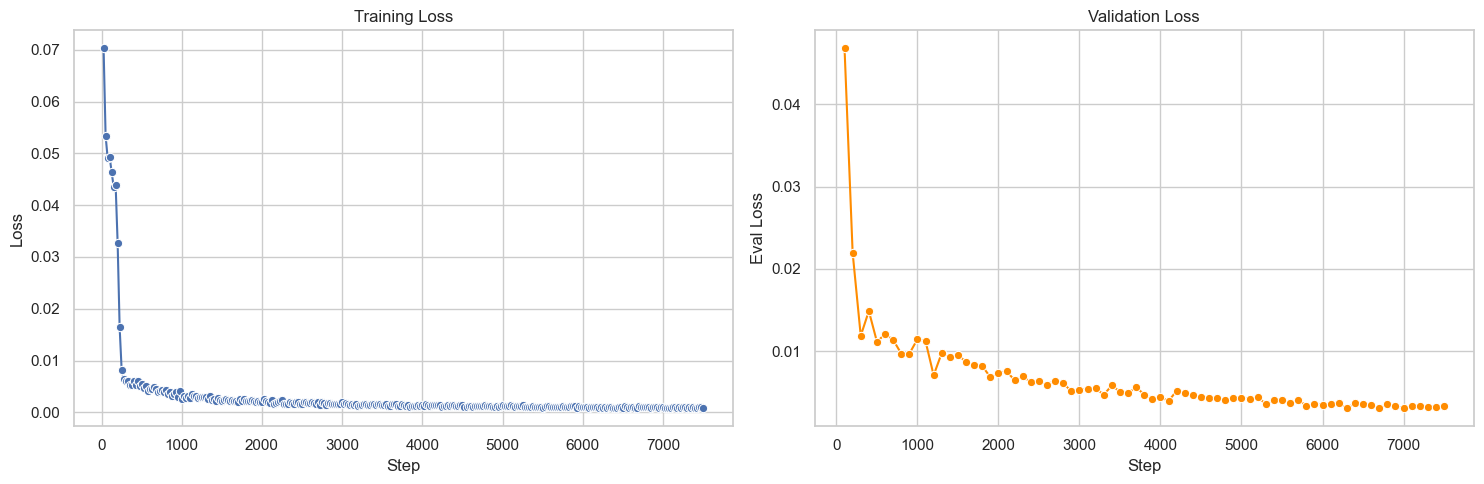

In [46]:
if history_df.empty:
    print("Belum ada history training. Jalankan training untuk melihat loss.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    if "loss" in history_df.columns:
        train_loss_plot = history_df.dropna(subset=["loss"])
        if not train_loss_plot.empty:
            sns.lineplot(data=train_loss_plot, x="step", y="loss", marker="o", ax=axes[0])
            axes[0].set_title("Training Loss")
            axes[0].set_xlabel("Step")
            axes[0].set_ylabel("Loss")
        else:
            axes[0].text(0.5, 0.5, "Tidak ada log training loss", ha="center")
    else:
        axes[0].text(0.5, 0.5, "Kolom loss tidak ditemukan", ha="center")

    if "eval_loss" in history_df.columns:
        eval_loss_plot = history_df.dropna(subset=["eval_loss"])
        if not eval_loss_plot.empty:
            sns.lineplot(data=eval_loss_plot, x="step", y="eval_loss", marker="o", color="darkorange", ax=axes[1])
            axes[1].set_title("Validation Loss")
            axes[1].set_xlabel("Step")
            axes[1].set_ylabel("Eval Loss")
        else:
            axes[1].text(0.5, 0.5, "Tidak ada log validation loss", ha="center")
    else:
        axes[1].text(0.5, 0.5, "Kolom eval_loss tidak ditemukan", ha="center")

    plt.tight_layout()
    plt.show()

## 7. Validasi Pair Similarity

In [47]:
def load_best_available_sbert() -> SentenceTransformer:
    if FINE_TUNED_MODEL_DIR.exists():
        print("Memakai fine-tuned model:", FINE_TUNED_MODEL_DIR)
        return SentenceTransformer(str(FINE_TUNED_MODEL_DIR))
    print("Fine-tuned model belum ada. Memakai base model:", BASE_MODEL_NAME)
    return SentenceTransformer(BASE_MODEL_NAME)


embedding_model = load_best_available_sbert()

Memakai fine-tuned model: f:\perkuliahan\Semester 6\SPK\project\parfum\Perfumes_Recommender-main\models\sbert_fuzzy_topsis\fine_tuned_model


In [48]:
def evaluate_pair_similarity(model: SentenceTransformer, pair_data: pd.DataFrame, batch_size: int = 64) -> tuple[dict, pd.DataFrame]:
    emb1 = model.encode(
        pair_data["sentence1"].tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    emb2 = model.encode(
        pair_data["sentence2"].tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    cosine = np.sum(emb1 * emb2, axis=1)
    predicted_score = np.clip((cosine + 1.0) / 2.0, 0.0, 1.0)
    actual_score = pair_data["score"].to_numpy()

    pearson_value = pearsonr(actual_score, predicted_score)[0]
    spearman_value = spearmanr(actual_score, predicted_score)[0]
    mae_value = mean_absolute_error(actual_score, predicted_score)
    rmse_value = math.sqrt(mean_squared_error(actual_score, predicted_score))

    result_df = pair_data[["idx1", "idx2", "score", "pair_type", "family1", "family2"]].copy()
    result_df["cosine"] = cosine
    result_df["predicted_score"] = predicted_score
    result_df["absolute_error"] = np.abs(result_df["score"] - result_df["predicted_score"])

    metrics = {
        "pearson": float(pearson_value),
        "spearman": float(spearman_value),
        "mae": float(mae_value),
        "rmse": float(rmse_value),
    }
    return metrics, result_df


pair_metrics, val_pair_predictions = evaluate_pair_similarity(embedding_model, val_pairs, batch_size=ENCODE_BATCH_SIZE)
display(pd.DataFrame([pair_metrics]))
display(val_pair_predictions.sort_values("absolute_error", ascending=False).head(10))

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

,pearson,spearman,mae,rmse
0,0.989578,0.964693,0.279125,0.294167


,idx1,idx2,score,pair_type,family1,family2,cosine,predicted_score,absolute_error
112,3258,864,0.1975,negative,Chypre,Oud,0.340119,0.670060,0.472560
220,646,1859,0.1300,negative,Soft Floral,Oriental,0.182873,0.591436,0.461436
1624,359,224,0.1300,negative,Floral,Oriental,0.176977,0.588488,0.458488
1685,2671,1737,0.1407,negative,Oriental,Aromatic,0.197469,0.598735,0.458035
642,163,1493,0.1300,negative,Soft Oriental,Aquatic,0.172782,0.586391,0.456391
790,2044,1491,0.1300,negative,Fruity,Aromatic,0.172244,0.586122,0.456122
2275,3235,2210,0.1394,negative,Aquatic,Aromatic,0.190911,0.595455,0.456055
1331,373,2239,0.1446,negative,Leather,Oriental,0.199316,0.599658,0.455058
566,2666,579,0.1300,negative,Aromatic,Citrus,0.168997,0.584499,0.454499
622,1128,979,0.1411,negative,Woody,Fruity,0.189100,0.594550,0.453450


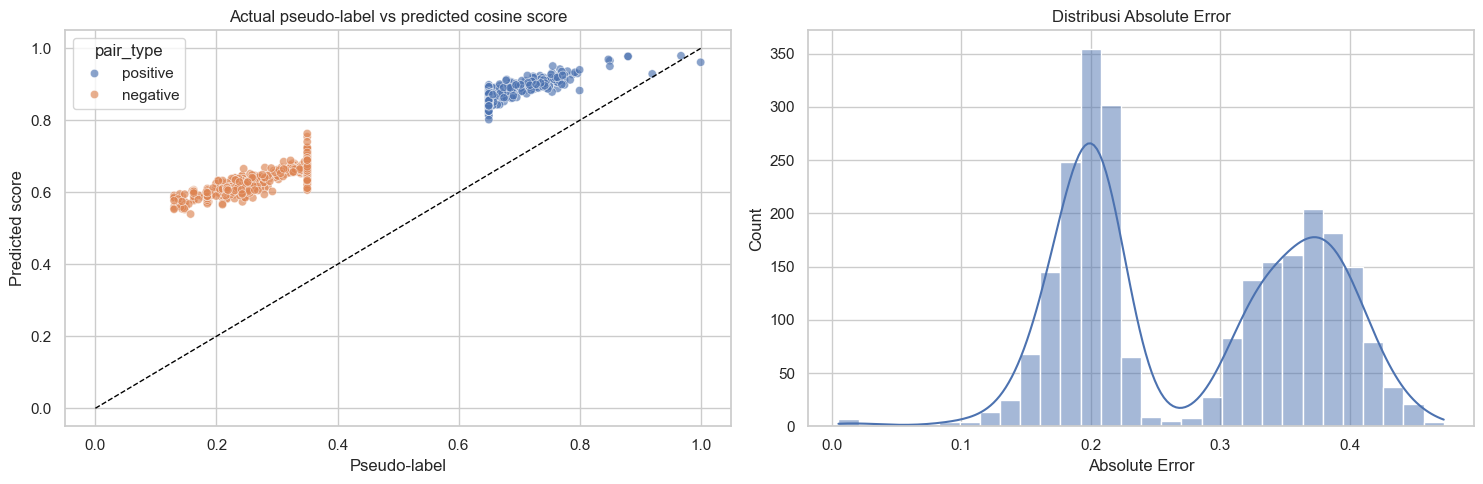

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=val_pair_predictions.sample(min(1000, len(val_pair_predictions)), random_state=SEED),
    x="score",
    y="predicted_score",
    hue="pair_type",
    alpha=0.65,
    ax=axes[0],
)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
axes[0].set_title("Actual pseudo-label vs predicted cosine score")
axes[0].set_xlabel("Pseudo-label")
axes[0].set_ylabel("Predicted score")

sns.histplot(val_pair_predictions["absolute_error"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribusi Absolute Error")
axes[1].set_xlabel("Absolute Error")

plt.tight_layout()
plt.show()

## 8. Embedding Parfum dan Cosine Similarity

In [50]:
embeddings_path = ARTIFACT_DIR / "perfume_embeddings.npy"

embeddings = embedding_model.encode(
    df["semantic_text"].tolist(),
    batch_size=ENCODE_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
np.save(embeddings_path, embeddings)

print("Shape embeddings:", embeddings.shape)
print("Embeddings disimpan ke:", embeddings_path)

Batches:   0%|          | 0/52 [00:00<?, ?it/s]

Shape embeddings: (3296, 384)
Embeddings disimpan ke: f:\perkuliahan\Semester 6\SPK\project\parfum\Perfumes_Recommender-main\models\sbert_fuzzy_topsis\perfume_embeddings.npy


In [51]:
def cosine_search(query: str, model: SentenceTransformer, data: pd.DataFrame, matrix: np.ndarray, top_n: int = 10) -> pd.DataFrame:
    query_embedding = model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True,
    )[0]
    scores = matrix @ query_embedding
    result = data.copy()
    result["cosine_similarity"] = scores
    return result.sort_values("cosine_similarity", ascending=False).head(top_n)


demo_query = "fresh floral jasmine citrus musk perfume for women daily use"
cosine_demo = cosine_search(demo_query, embedding_model, df, embeddings, top_n=10)
display(cosine_demo[[
    "name", "brand", "gender", "fragrance_family", "price", "rating",
    "top_note", "middle_note", "base_note", "cosine_similarity",
]])

,name,brand,gender,fragrance_family,price,rating,top_note,middle_note,base_note,cosine_similarity
2677,LancÃƒÂ´me La Nuit Tresor Musc Diamant,Lancome,Women,Floral Oriental,475,0.0,"raspberry, violet leaf, white musk","damask rose, freesia, jasmine petals, white musk","white musk, sandalwood, almond, patchouli, vanilla",0.398712
1866,Gucci The Virgin Violet EDP,Gucci,Women,Floral Oriental,1440,0.0,vanilla,musk,"iris, violet",0.372663
2759,Kenzo Jeu D'Amour L' Elixir Intense,Kenzo,Women,Floral Oriental,270,0.0,"blackberry, mandarin, orange","tuberose, jasmine, rum","rum, vanilla, patchouli, caramel, sandalwood.",0.363098
2676,LancÃƒÂ´me La Vie Est Belle L'Eclat L'Eau,Lancome,Women,Floral Oriental,464,0.0,"bergamot oil, grapefruit oil, mandarin oil, pink pepper oil, tea accord","neroli oil, sambac jasmine absolute, orange blossom absolute, turkish rose oil","iris concrete, patchouli oil, ambroxan, musks",0.360533
2723,Lancome IdÃƒÂ´le L'Intense Gift Box,Lancome,Women,Floral Oriental,519,0.0,"mandarin, bitter orange","musk, jasmine, jasmine sambac, egyptian jasmine, rose grass, turkish rose","sandalwood, cedar, madagascar vanilla, cashmere wood, patchouli, acacia",0.359403
3284,Laboratorio Olfattivo Decou,Laboratorio Olfattivo,Women,Floral Oriental,306,0.0,rose and saffron,"white lotus, jasmine and ylang-ylang","sandalwood, tonka bean, virginia cedar and incense",0.358988
2674,Lancome Tresor,Lancome,Women,Floral Oriental,519,0.0,apricot blossom and rose,"lilac, iris and peach","amber, sandalwood, musk and vanilla",0.353517
3224,The Merchant of Venice Suave Petals Murano Collection EDP,PH,Women,Floral Oriental,725,0.0,"bitter orange, ginger, bergamot,","sage,lavander,nutme,saffron","amber,vetiver,cedar,musk",0.349546
290,Dolce & Gabbana The Only One Hair Mist,Dolce & Gabbana,Women,Floral Oriental,219,0.0,"violet, bergamot","coffee, iris","vanilla, patchouli",0.346932
601,Mercedes Benz Woman,Mercedes Benz,Women,Floral Oriental,240,0.0,"pears, black currant leaves, gardenia","jasmine, orange blossom","cashmere wood, sandalwood, musk, vanilla.",0.344301


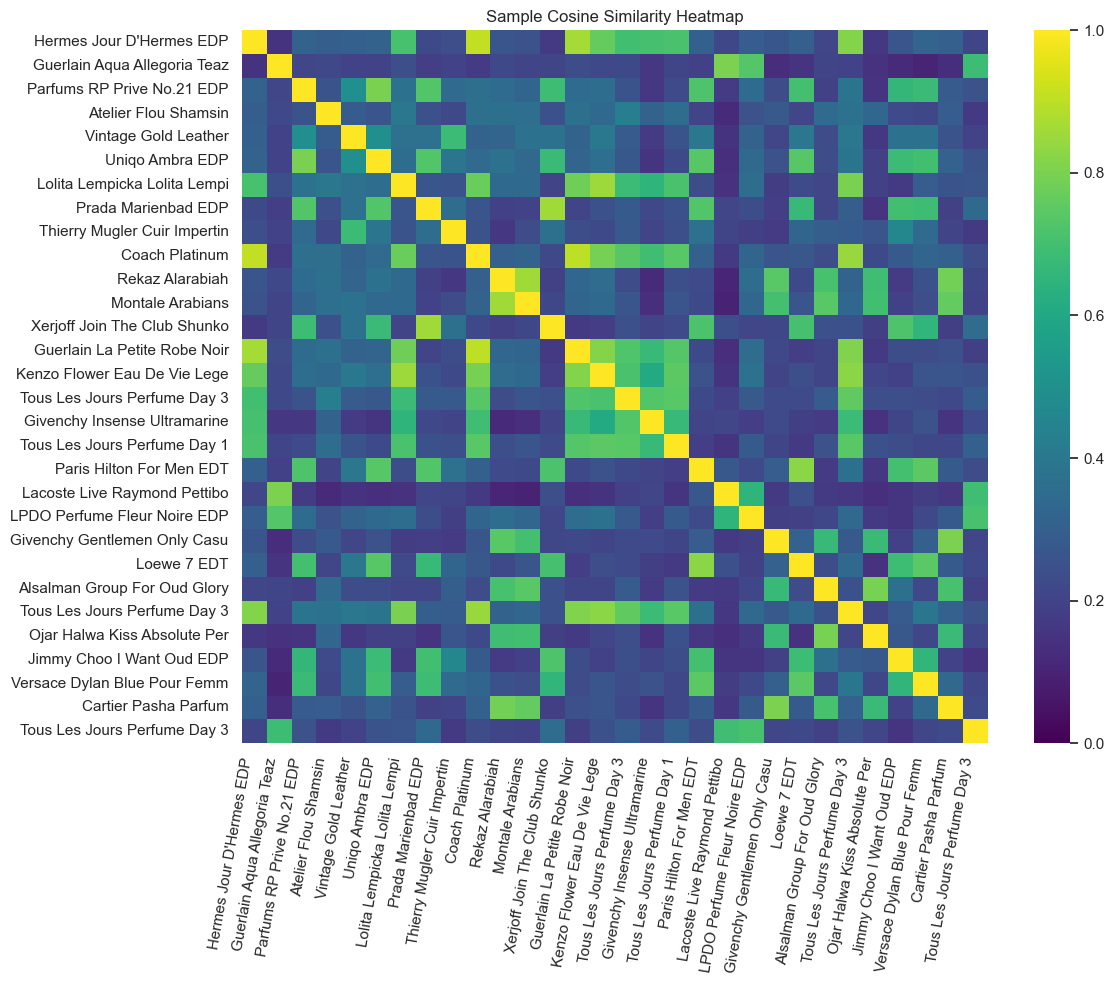

In [52]:
sample_idx = np.random.default_rng(SEED).choice(len(df), size=min(30, len(df)), replace=False)
sample_similarity = embeddings[sample_idx] @ embeddings[sample_idx].T
sample_names = df.iloc[sample_idx]["name"].str.slice(0, 28).tolist()

plt.figure(figsize=(12, 10))
sns.heatmap(
    sample_similarity,
    xticklabels=sample_names,
    yticklabels=sample_names,
    cmap="viridis",
    vmin=0,
    vmax=1,
)
plt.title("Sample Cosine Similarity Heatmap")
plt.xticks(rotation=80, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

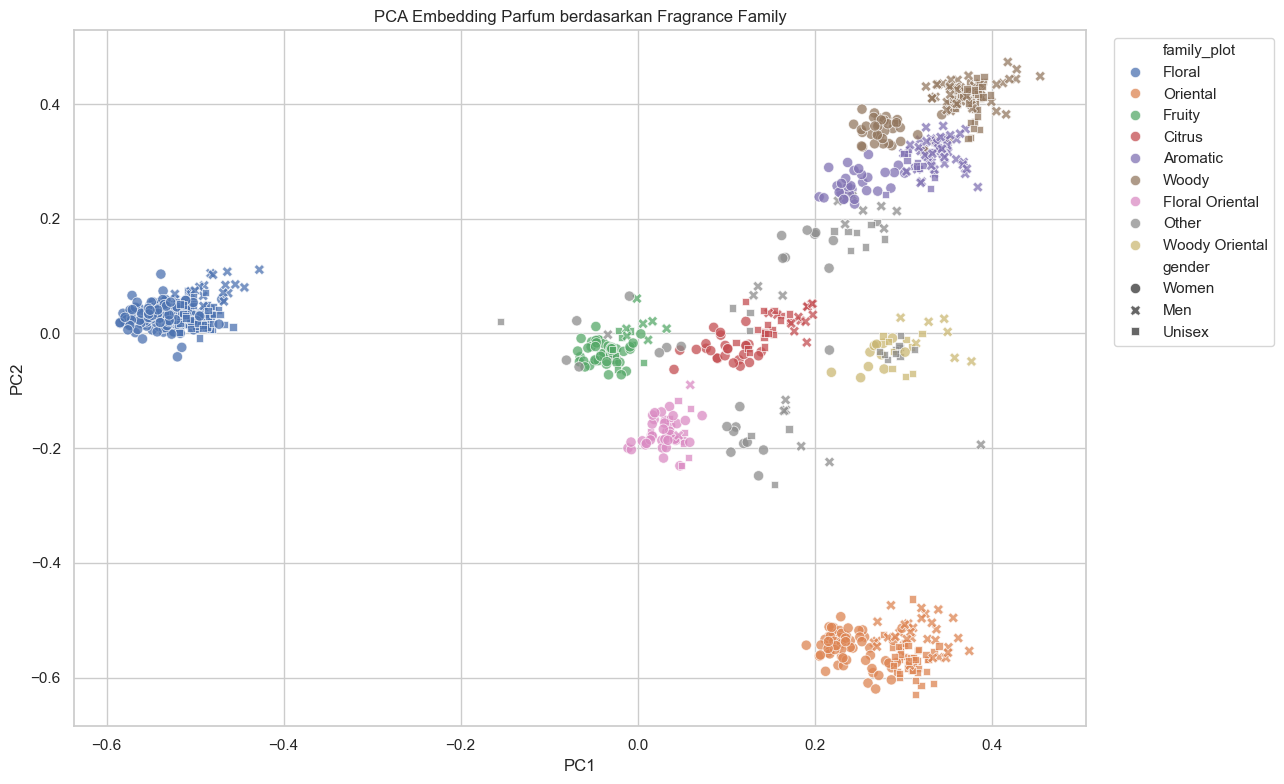

In [53]:
visual_size = min(900, len(df))
visual_idx = np.random.default_rng(SEED).choice(len(df), size=visual_size, replace=False)
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(embeddings[visual_idx])

visual_df = df.iloc[visual_idx][["name", "fragrance_family", "gender"]].copy()
visual_df["pc1"] = coords[:, 0]
visual_df["pc2"] = coords[:, 1]

top_families = visual_df["fragrance_family"].value_counts().head(8).index
visual_df["family_plot"] = np.where(visual_df["fragrance_family"].isin(top_families), visual_df["fragrance_family"], "Other")

plt.figure(figsize=(13, 8))
sns.scatterplot(
    data=visual_df,
    x="pc1",
    y="pc2",
    hue="family_plot",
    style="gender",
    alpha=0.75,
    s=55,
)
plt.title("PCA Embedding Parfum berdasarkan Fragrance Family")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 9. Fuzzy TOPSIS untuk Ranking Rekomendasi

Semua kriteria diubah menjadi membership fuzzy 0 sampai 1, lalu diproses dengan TOPSIS.
Karena semua kriteria sudah menjadi benefit score, solusi ideal positif adalah nilai maksimum
tiap kriteria dan solusi ideal negatif adalah nilai minimum tiap kriteria.

In [54]:
USAGE_KEYWORDS = {
    "daily": {"fresh", "citrus", "aquatic", "clean", "light", "green"},
    "campus": {"fresh", "citrus", "fruity", "aquatic", "light"},
    "work": {"woody", "floral", "musk", "aromatic", "clean", "elegant"},
    "formal": {"woody", "amber", "musk", "oriental", "leather", "sophisticated"},
    "date": {"sweet", "floral", "musk", "vanilla", "romantic", "warm"},
    "night": {"amber", "oriental", "musk", "vanilla", "woody", "leather"},
}

AGE_RULES = [
    (0, 20, {"fresh", "citrus", "fruity", "sweet"}),
    (21, 30, {"fresh", "aquatic", "floral", "woody", "sweet"}),
    (31, 45, {"woody", "spicy", "amber", "musk", "aromatic", "oud"}),
    (46, 200, {"oriental", "leather", "amber", "powdery", "musk", "oud"}),
]

DEFAULT_WEIGHTS = {
    "semantic_similarity": 0.30,
    "family_fit": 0.16,
    "gender_fit": 0.12,
    "age_fit": 0.08,
    "usage_fit": 0.10,
    "rating_fit": 0.10,
    "popularity_fit": 0.05,
    "budget_fit": 0.09,
}


def normalize_weights(weights: dict[str, float]) -> dict[str, float]:
    total = sum(max(float(value), 0.0) for value in weights.values())
    if total <= 0:
        raise ValueError("Total weight harus lebih dari 0.")
    return {key: max(float(value), 0.0) / total for key, value in weights.items()}


def age_terms(age: int) -> set[str]:
    for lower, upper, terms in AGE_RULES:
        if lower <= age <= upper:
            return terms
    return AGE_RULES[-1][2]


def fuzzy_gender_fit(user_gender: str, perfume_gender: str) -> float:
    user = normalize_gender(user_gender)
    perfume = normalize_gender(perfume_gender)
    if not user:
        return 0.7
    if user == perfume:
        return 1.0
    if perfume == "Unisex":
        return 0.85
    if user == "Unisex" and perfume in {"Men", "Women"}:
        return 0.75
    return 0.25


def fuzzy_family_fit(preferred_family: str, row_family: str, aroma_keywords: str, note_terms: set[str]) -> float:
    preferred = normalize_text(preferred_family)
    row = normalize_text(row_family)
    preferred_terms = split_terms(preferred_family, aroma_keywords)

    if not preferred and not preferred_terms:
        return 0.65
    if preferred and preferred == row:
        return 1.0
    if preferred and (preferred in row or row in preferred):
        return 0.9
    if preferred_terms and preferred_terms & note_terms:
        return 0.8
    if related_family_score(preferred, row) >= 0.65:
        return 0.7
    return 0.25


def fuzzy_usage_fit(usage: str, note_terms: set[str]) -> float:
    usage_key = normalize_text(usage)
    target_terms = USAGE_KEYWORDS.get(usage_key, set())
    if not target_terms:
        return 0.65
    overlap = len(target_terms & note_terms)
    if overlap >= 3:
        return 1.0
    if overlap == 2:
        return 0.8
    if overlap == 1:
        return 0.55
    return 0.25


def fuzzy_age_fit(age: int, note_terms: set[str]) -> float:
    target_terms = age_terms(int(age))
    overlap = len(target_terms & note_terms)
    if overlap >= 2:
        return 1.0
    if overlap == 1:
        return 0.7
    return 0.35


def fuzzy_rating_fit(rating: float, rating_count: int) -> float:
    rating_norm = float(np.clip(rating / 5.0, 0.0, 1.0))
    confidence = float(np.clip(np.log1p(max(rating_count, 0)) / np.log1p(20), 0.0, 1.0))
    return float(np.clip((0.75 * rating_norm) + (0.25 * rating_norm * confidence), 0.0, 1.0))


def fuzzy_popularity_fit(rating_count: int) -> float:
    return float(np.clip(np.log1p(max(rating_count, 0)) / np.log1p(max(df["rating_count"].max(), 1)), 0.0, 1.0))


def fuzzy_budget_fit(price: float, budget: float) -> float:
    price = float(price)
    budget = float(budget or 0)
    if budget <= 0:
        return 0.70
    if price <= budget:
        return 1.0
    if price <= budget * 1.15:
        return 0.75
    if price <= budget * 1.35:
        return 0.45
    return 0.15


def build_preference_query(preference: dict) -> str:
    usage = normalize_text(preference.get("usage", "daily"))
    usage_terms = " ".join(sorted(USAGE_KEYWORDS.get(usage, set())))
    age_text = " ".join(sorted(age_terms(int(preference.get("age", 25)))))
    parts = [
        preference.get("fragrance_family", ""),
        preference.get("aroma_keywords", ""),
        usage_terms,
        age_text,
        preference.get("gender", ""),
    ]
    return " ".join(clean_text(part) for part in parts if clean_text(part)) or "fresh floral woody citrus musk"

In [55]:
def fuzzy_topsis(decision_matrix: pd.DataFrame, weights: dict[str, float]) -> pd.DataFrame:
    weights = normalize_weights(weights)
    criteria = list(weights.keys())
    X = decision_matrix[criteria].astype(float).clip(0.0, 1.0).to_numpy()

    norm = np.sqrt((X ** 2).sum(axis=0))
    norm[norm == 0] = 1.0
    R = X / norm

    weight_vector = np.array([weights[c] for c in criteria])
    V = R * weight_vector

    ideal_positive = V.max(axis=0)
    ideal_negative = V.min(axis=0)

    distance_positive = np.sqrt(((V - ideal_positive) ** 2).sum(axis=1))
    distance_negative = np.sqrt(((V - ideal_negative) ** 2).sum(axis=1))
    closeness = distance_negative / (distance_positive + distance_negative + 1e-12)

    result = decision_matrix.copy()
    result["distance_positive"] = distance_positive
    result["distance_negative"] = distance_negative
    result["topsis_score"] = closeness
    return result


def recommend_with_fuzzy_topsis(
    preference: dict,
    model: SentenceTransformer,
    data: pd.DataFrame,
    matrix: np.ndarray,
    weights: dict[str, float] | None = None,
    top_n: int = 10,
    candidate_pool: int = 500,
) -> pd.DataFrame:
    weights = normalize_weights(weights or DEFAULT_WEIGHTS)
    query = build_preference_query(preference)
    query_embedding = model.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
    cosine_scores = matrix @ query_embedding

    candidate_pool = min(candidate_pool, len(data))
    candidate_indices = np.argsort(cosine_scores)[::-1][:candidate_pool]
    candidates = data.iloc[candidate_indices].copy()
    candidates["cosine_similarity"] = cosine_scores[candidate_indices]

    criteria_rows = []
    for idx, row in candidates.iterrows():
        semantic_similarity = float(np.clip((row["cosine_similarity"] + 1.0) / 2.0, 0.0, 1.0))
        criteria_rows.append({
            "perfume_id": row["perfume_id"],
            "semantic_similarity": semantic_similarity,
            "family_fit": fuzzy_family_fit(
                preference.get("fragrance_family", ""),
                row["fragrance_family"],
                preference.get("aroma_keywords", ""),
                row["note_terms"],
            ),
            "gender_fit": fuzzy_gender_fit(preference.get("gender", "Unisex"), row["gender"]),
            "age_fit": fuzzy_age_fit(int(preference.get("age", 25)), row["note_terms"]),
            "usage_fit": fuzzy_usage_fit(preference.get("usage", "daily"), row["note_terms"]),
            "rating_fit": fuzzy_rating_fit(row["rating"], row["rating_count"]),
            "popularity_fit": fuzzy_popularity_fit(row["rating_count"]),
            "budget_fit": fuzzy_budget_fit(row["price"], float(preference.get("budget", 0) or 0)),
        })

    criteria_df = pd.DataFrame(criteria_rows).set_index(candidates.index)
    scored = fuzzy_topsis(criteria_df.drop(columns=["perfume_id"]), weights)
    ranked = pd.concat([candidates, scored], axis=1)
    ranked = ranked.sort_values(
        ["topsis_score", "cosine_similarity", "rating", "rating_count"],
        ascending=[False, False, False, False],
    ).head(top_n)
    ranked["rank"] = range(1, len(ranked) + 1)
    ranked["preference_query"] = query
    return ranked

## 10. Demo Rekomendasi

In [56]:
demo_preference = {
    "gender": "Women",
    "age": 24,
    "fragrance_family": "Floral",
    "aroma_keywords": "jasmine vanilla musk fresh romantic",
    "budget": 400,
    "usage": "date",
}

demo_recommendations = recommend_with_fuzzy_topsis(
    demo_preference,
    embedding_model,
    df,
    embeddings,
    weights=DEFAULT_WEIGHTS,
    top_n=10,
    candidate_pool=600,
)

display(demo_recommendations[[
    "rank", "name", "brand", "gender", "fragrance_family", "price", "rating",
    "rating_count", "top_note", "middle_note", "base_note",
    "cosine_similarity", "semantic_similarity", "family_fit", "gender_fit",
    "age_fit", "usage_fit", "rating_fit", "popularity_fit", "budget_fit",
    "topsis_score",
]])

,rank,name,brand,gender,fragrance_family,price,rating,rating_count,top_note,middle_note,base_note,cosine_similarity,semantic_similarity,family_fit,gender_fit,age_fit,usage_fit,rating_fit,popularity_fit,budget_fit,topsis_score
1,1,Roberto Cavalli Paradiso,Roberto Cavalli,Women,Woody,169,4.95,17,"citruses , mandarin , bergamot",jasmine,"cypress, parasol pine, pink laurel",0.390829,0.695414,0.8,1.0,0.70,0.55,0.977469,0.981638,1.00,0.890190
310,2,Who Am I Just Fly EDP,The Different Company,Women,Woody,149,4.92,7,grapefruit,orris,cedarwood,0.419677,0.709839,0.8,1.0,0.70,0.55,0.906021,0.706227,1.00,0.778594
5,3,Versace Eros Pour Femme EDP,Versace,Women,Woody,229,4.79,7,"sicilian lemon, calabrian bergamot, pomegranate","lemon, sambac jasmine, peony","sandalwood, ambrox, musk,woods",0.368642,0.684321,0.8,1.0,0.70,0.55,0.882081,0.706227,1.00,0.771651
0,4,Dolce & Gabanna L'imperatrice 3 Pour Femme,Dolce&Gabbana,Women,Floral,199,5.00,6,"pink pepper, kiwi, rhubarb","jasmine, cyclamen, watermelon","musk, sandalwood, lemon trees.",0.334869,0.667434,1.0,1.0,0.70,1.00,0.909788,0.660876,1.00,0.771035
16,5,Juicy Couture Viva La Juicy,Juicy Couture,Women,Fruity,252,4.75,6,"mandarin, cranberry","capricorn, gardenia, jasmine,","amber, caramel, almond candy, sandalwood, vanilla",0.342026,0.671013,0.8,1.0,0.35,0.80,0.864298,0.660876,1.00,0.735466
43,6,Gucci Flora By Gucci EDP,Gucci,Women,Floral,302,5.00,4,"mandarin, peony","rose, pink pepper, osmanthus flower","patchouli, sandalwood, vanilla",0.364161,0.682080,1.0,1.0,0.70,1.00,0.882158,0.546603,1.00,0.704030
95,7,Lancome Idole,Lancome,Women,Floral,412,5.00,4,"bergamot (citrus),juicy pear, pink peppercorn","rose, jasmine","white musk, vanilla, patchouli, cedarwood",0.394176,0.697088,1.0,1.0,0.70,1.00,0.882158,0.546603,0.75,0.700107
2,8,Yves Saint Laurent Libre,Yves Saint Laurent,Women,Floral,389,5.00,3,"mandarin orange, lavendar, black currant, petitgrain","jasmine, orange blossom","vanilla, cedar, musk, ambergris",0.359774,0.679887,1.0,1.0,0.70,1.00,0.863835,0.470818,1.00,0.660506
14,9,Roberto Cavalli Paradiso Azzurro,Roberto Cavalli,Women,Floral,174,5.00,3,"citrus, bergamot, lavender","wild jasmine, petals","cypress, cashmere woods",0.356881,0.678441,1.0,1.0,0.70,0.80,0.863835,0.470818,1.00,0.657435
352,10,Candy Addict Addictive Temptation Mini Hair Mists Set,Candy Addict,Women,Floral,149,4.75,3,unknown,unknown,unknown,0.348341,0.674171,1.0,1.0,0.70,0.80,0.820643,0.470818,1.00,0.646868


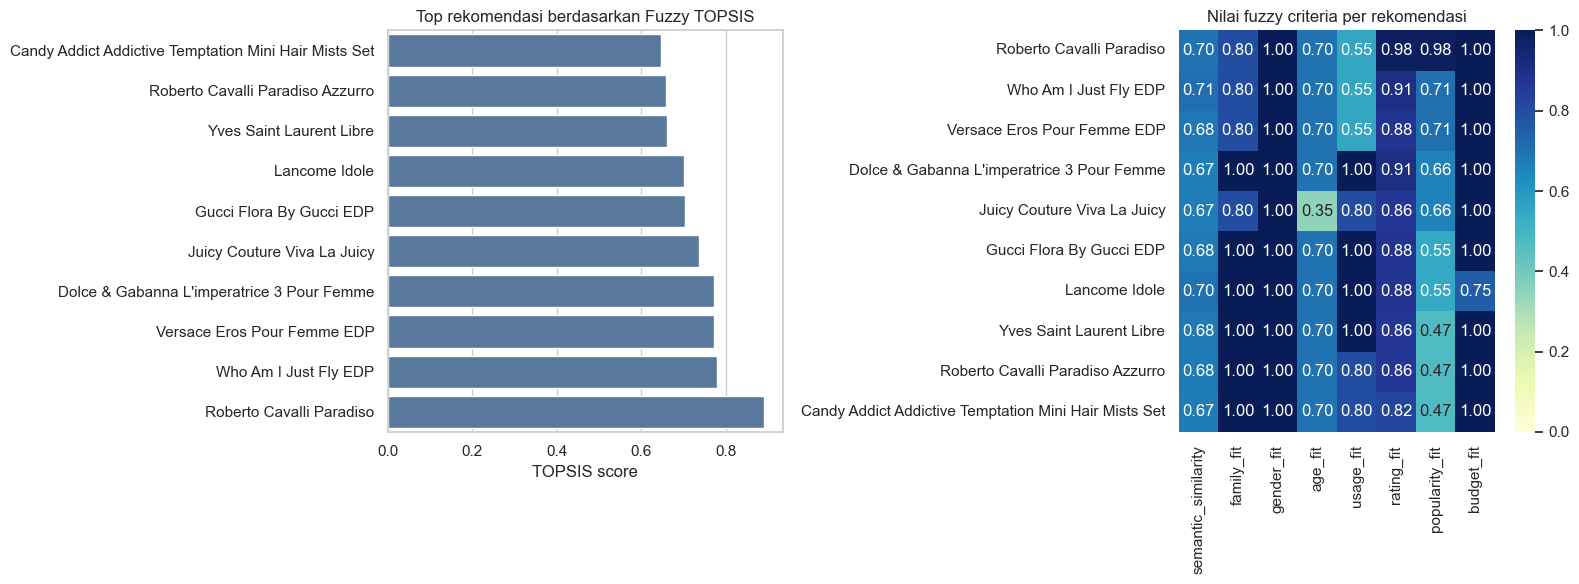

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = demo_recommendations.sort_values("topsis_score", ascending=True)
sns.barplot(data=plot_df, x="topsis_score", y="name", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top rekomendasi berdasarkan Fuzzy TOPSIS")
axes[0].set_xlabel("TOPSIS score")
axes[0].set_ylabel("")

criteria_cols = list(DEFAULT_WEIGHTS.keys())
sns.heatmap(
    demo_recommendations.set_index("name")[criteria_cols],
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    ax=axes[1],
)
axes[1].set_title("Nilai fuzzy criteria per rekomendasi")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

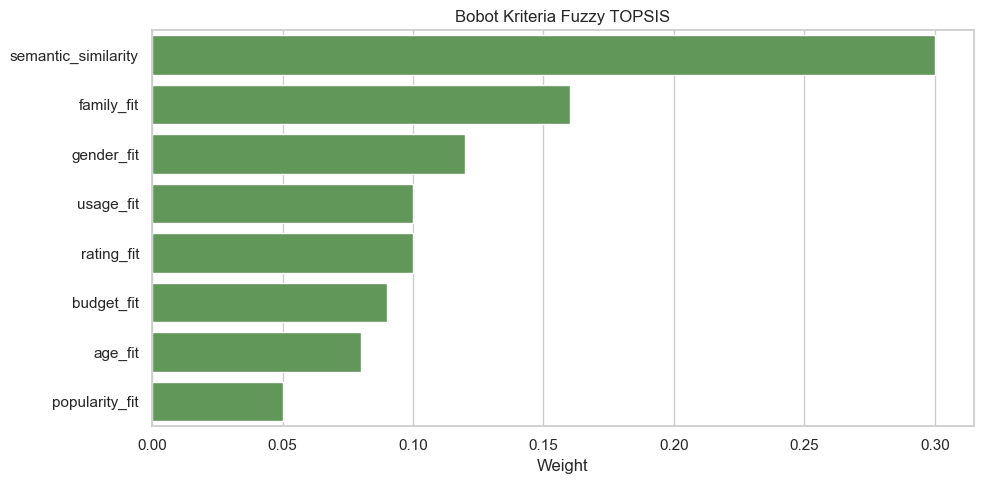

In [58]:
weight_df = pd.DataFrame({
    "criteria": list(normalize_weights(DEFAULT_WEIGHTS).keys()),
    "weight": list(normalize_weights(DEFAULT_WEIGHTS).values()),
}).sort_values("weight", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=weight_df, x="weight", y="criteria", color="#59A14F")
plt.title("Bobot Kriteria Fuzzy TOPSIS")
plt.xlabel("Weight")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 11. Evaluasi Retrieval Top-K

Evaluasi ini memakai proxy relevance:

- Relevan jika fragrance family sama.
- Atau family masih terkait dan overlap notes cukup kuat.
- Query evaluasi memakai setiap parfum sebagai query leave-one-out.

Metrik yang dihitung: Precision@K, Recall@K, HitRate@K, MRR@K, MAP@K, dan nDCG@K.

In [59]:
def relevant_indices_for_item(item_idx: int, data: pd.DataFrame, min_note_overlap: int = 2) -> set[int]:
    query_row = data.iloc[item_idx]
    relevant = set()
    query_family = query_row["fragrance_family_norm"]
    query_terms = query_row["note_terms"]

    for idx, row in data.iterrows():
        if idx == item_idx:
            continue
        same_family = row["fragrance_family_norm"] == query_family
        related_family = related_family_score(query_row["fragrance_family"], row["fragrance_family"]) >= 0.65
        overlap = len(query_terms & row["note_terms"])
        if same_family or (related_family and overlap >= min_note_overlap):
            relevant.add(idx)
    return relevant


def average_precision_at_k(ranked_indices: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return np.nan
    score = 0.0
    hits = 0
    for rank, idx in enumerate(ranked_indices[:k], start=1):
        if idx in relevant:
            hits += 1
            score += hits / rank
    return score / min(len(relevant), k)


def ndcg_at_k(ranked_indices: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return np.nan
    gains = np.array([1.0 if idx in relevant else 0.0 for idx in ranked_indices[:k]])
    discounts = 1 / np.log2(np.arange(2, len(gains) + 2))
    dcg = float(np.sum(gains * discounts))
    ideal_hits = min(len(relevant), k)
    ideal_gains = np.ones(ideal_hits)
    ideal_discounts = 1 / np.log2(np.arange(2, ideal_hits + 2))
    idcg = float(np.sum(ideal_gains * ideal_discounts))
    return dcg / idcg if idcg > 0 else np.nan


def evaluate_retrieval(
    matrix: np.ndarray,
    data: pd.DataFrame,
    query_count: int,
    k_values: list[int],
    seed: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    query_indices = rng.choice(len(data), size=min(query_count, len(data)), replace=False)
    max_k = max(k_values)
    rows = []

    for query_idx in query_indices:
        relevant = relevant_indices_for_item(int(query_idx), data)
        if not relevant:
            continue

        scores = matrix @ matrix[query_idx]
        scores[query_idx] = -np.inf
        ranked_indices = np.argsort(scores)[::-1][:max_k].tolist()

        for k in k_values:
            top_k = ranked_indices[:k]
            hits = sum(1 for idx in top_k if idx in relevant)
            first_hit_rank = next((rank for rank, idx in enumerate(top_k, start=1) if idx in relevant), None)
            rows.append({
                "k": k,
                "precision": hits / k,
                "recall": hits / len(relevant),
                "hit_rate": 1.0 if hits > 0 else 0.0,
                "mrr": 1.0 / first_hit_rank if first_hit_rank else 0.0,
                "map": average_precision_at_k(ranked_indices, relevant, k),
                "ndcg": ndcg_at_k(ranked_indices, relevant, k),
                "relevant_count": len(relevant),
            })

    return pd.DataFrame(rows).groupby("k", as_index=False).mean(numeric_only=True)


retrieval_metrics_df = evaluate_retrieval(
    embeddings.copy(),
    df,
    query_count=RETRIEVAL_EVAL_QUERIES,
    k_values=TOP_K_VALUES,
    seed=SEED,
)
display(retrieval_metrics_df)

,k,precision,recall,hit_rate,mrr,map,ndcg,relevant_count
0,5,0.9992,0.006968,1.0,1.0,0.999200,0.999445,953.396
1,10,0.9990,0.013931,1.0,1.0,0.998825,0.999217,953.396
2,20,0.9988,0.027673,1.0,1.0,0.998428,0.999025,953.396


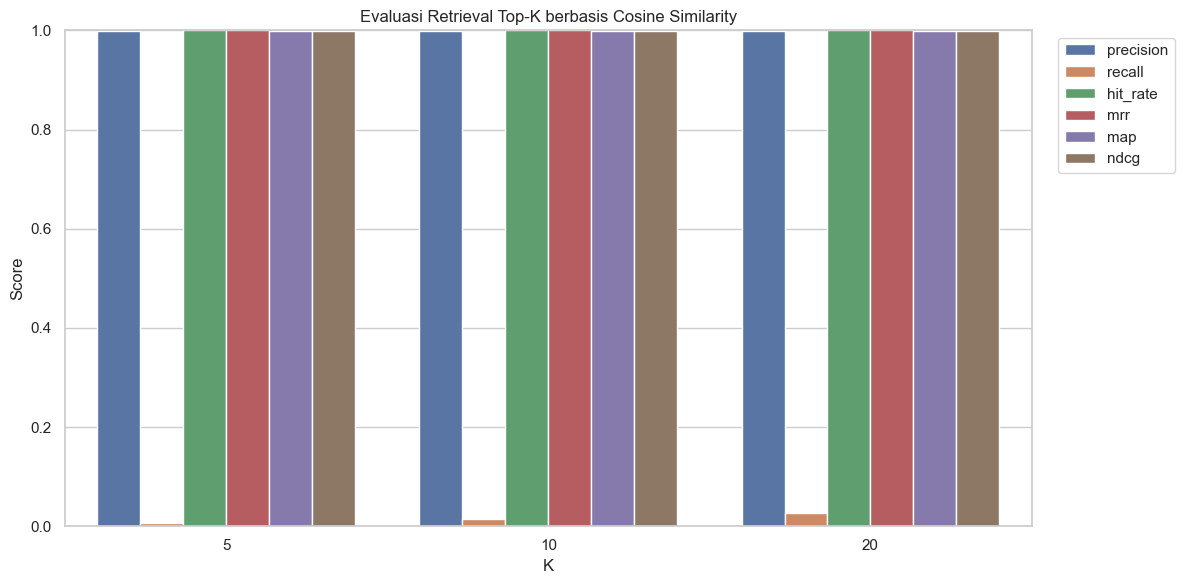

In [60]:
metric_plot = retrieval_metrics_df.melt(
    id_vars="k",
    value_vars=["precision", "recall", "hit_rate", "mrr", "map", "ndcg"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=metric_plot, x="k", y="value", hue="metric")
plt.title("Evaluasi Retrieval Top-K berbasis Cosine Similarity")
plt.ylim(0, 1)
plt.xlabel("K")
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 12. Evaluasi Skenario Fuzzy TOPSIS

In [61]:
scenario_preferences = [
    {
        "scenario": "Daily fresh untuk wanita muda",
        "gender": "Women",
        "age": 22,
        "fragrance_family": "Citrus",
        "aroma_keywords": "fresh citrus aquatic clean",
        "budget": 300,
        "usage": "daily",
    },
    {
        "scenario": "Formal woody untuk pria dewasa",
        "gender": "Men",
        "age": 35,
        "fragrance_family": "Woody",
        "aroma_keywords": "woody amber musk sophisticated",
        "budget": 500,
        "usage": "formal",
    },
    {
        "scenario": "Romantic floral date night",
        "gender": "Women",
        "age": 27,
        "fragrance_family": "Floral",
        "aroma_keywords": "jasmine vanilla musk romantic sweet",
        "budget": 450,
        "usage": "date",
    },
    {
        "scenario": "Unisex office clean aromatic",
        "gender": "Unisex",
        "age": 31,
        "fragrance_family": "Aromatic",
        "aroma_keywords": "clean aromatic musk woody",
        "budget": 400,
        "usage": "work",
    },
]

scenario_rows = []
scenario_rankings = {}

for preference in scenario_preferences:
    ranked = recommend_with_fuzzy_topsis(
        preference,
        embedding_model,
        df,
        embeddings,
        weights=DEFAULT_WEIGHTS,
        top_n=10,
        candidate_pool=600,
    )
    scenario_rankings[preference["scenario"]] = ranked
    criteria_cols = list(DEFAULT_WEIGHTS.keys())
    scenario_rows.append({
        "scenario": preference["scenario"],
        "mean_topsis_score": ranked["topsis_score"].mean(),
        "mean_cosine_similarity": ranked["cosine_similarity"].mean(),
        "mean_criteria_score": ranked[criteria_cols].mean(axis=1).mean(),
        "family_hit_rate": (ranked["family_fit"] >= 0.8).mean(),
        "gender_fit_rate": (ranked["gender_fit"] >= 0.75).mean(),
        "budget_fit_rate": (ranked["budget_fit"] >= 0.75).mean(),
        "rating_fit_mean": ranked["rating_fit"].mean(),
    })

scenario_eval_df = pd.DataFrame(scenario_rows)
display(scenario_eval_df)

,scenario,mean_topsis_score,mean_cosine_similarity,mean_criteria_score,family_hit_rate,gender_fit_rate,budget_fit_rate,rating_fit_mean
0,Daily fresh untuk wanita muda,0.623040,0.279078,0.684170,0.4,0.9,0.9,0.833459
1,Formal woody untuk pria dewasa,0.740509,0.376493,0.795736,0.7,0.9,1.0,0.837686
2,Romantic floral date night,0.726840,0.374270,0.823064,1.0,1.0,1.0,0.885229
3,Unisex office clean aromatic,0.757948,0.346699,0.800518,1.0,1.0,1.0,0.849649


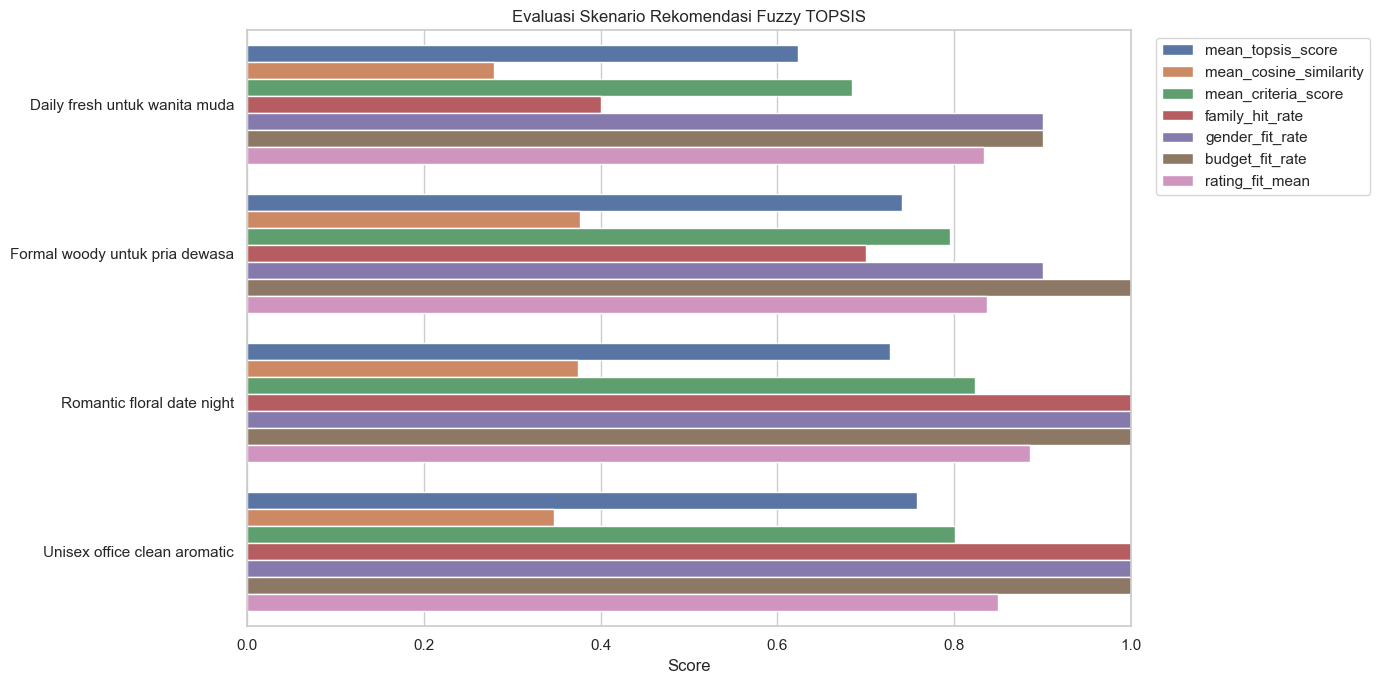

In [62]:
scenario_plot = scenario_eval_df.melt(
    id_vars="scenario",
    value_vars=[
        "mean_topsis_score", "mean_cosine_similarity", "mean_criteria_score",
        "family_hit_rate", "gender_fit_rate", "budget_fit_rate", "rating_fit_mean",
    ],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(14, 7))
sns.barplot(data=scenario_plot, x="value", y="scenario", hue="metric")
plt.title("Evaluasi Skenario Rekomendasi Fuzzy TOPSIS")
plt.xlim(0, 1)
plt.xlabel("Score")
plt.ylabel("")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

,rank,name,brand,gender,fragrance_family,price,rating,cosine_similarity,topsis_score
1,1,Roberto Cavalli Paradiso,Roberto Cavalli,Women,Woody,169,4.95,0.295415,0.877027
310,2,Who Am I Just Fly EDP,The Different Company,Women,Woody,149,4.92,0.317076,0.699046
5,3,Versace Eros Pour Femme EDP,Versace,Women,Woody,229,4.79,0.273695,0.693652
311,4,Who Am I Just Right EDP,The Different Company,Men,Citrus,149,5.00,0.325653,0.632681
138,5,Burberry Body,Burberry,Women,Floral,214,4.50,0.241057,0.580976
139,6,Burberry Body,Burberry,Women,Fruity,214,4.50,0.243334,0.558670
389,7,Dkhoun Thaty,Dkhoun,Women,Woody,253,5.00,0.317329,0.554126
363,8,Coach Coach Women,Coach,Women,Woody,231,5.00,0.251099,0.553412
2387,9,Jovan White Musk,Jovan,Women,Aquatic,39,4.00,0.241893,0.542752
220,10,Guerlain Mon Guerlain,Guerlain,Women,Woody Oriental,483,5.00,0.284231,0.538057


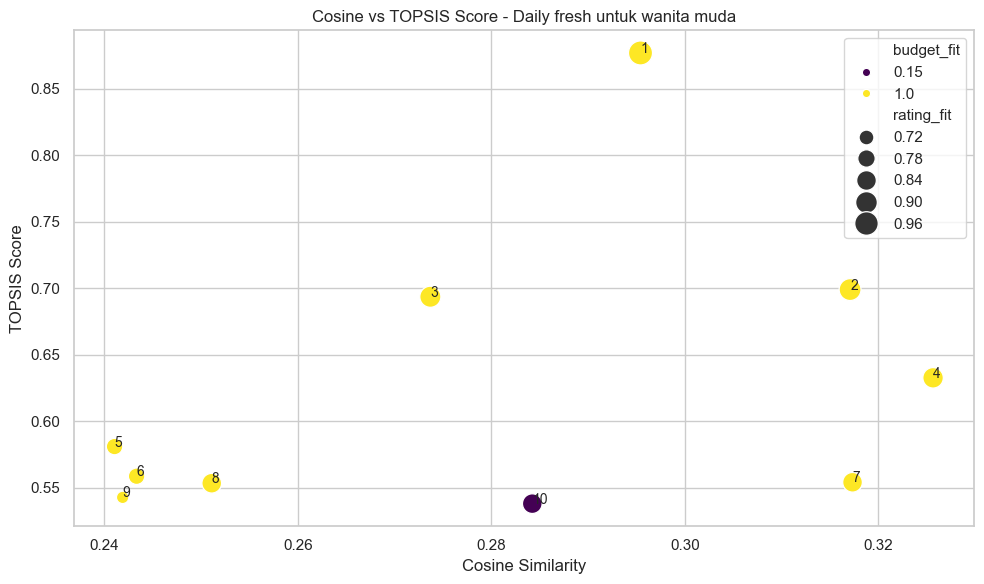

In [63]:
selected_scenario = scenario_preferences[0]["scenario"]
selected_ranking = scenario_rankings[selected_scenario]

display(selected_ranking[[
    "rank", "name", "brand", "gender", "fragrance_family", "price",
    "rating", "cosine_similarity", "topsis_score",
]])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=selected_ranking,
    x="cosine_similarity",
    y="topsis_score",
    size="rating_fit",
    hue="budget_fit",
    sizes=(80, 300),
    palette="viridis",
)
for _, row in selected_ranking.iterrows():
    plt.text(row["cosine_similarity"], row["topsis_score"], str(int(row["rank"])), fontsize=10)
plt.title(f"Cosine vs TOPSIS Score - {selected_scenario}")
plt.xlabel("Cosine Similarity")
plt.ylabel("TOPSIS Score")
plt.tight_layout()
plt.show()

## 13. Analisis Sensitivitas Bobot

In [64]:
def weight_sensitivity_analysis(
    preference: dict,
    base_weights: dict[str, float],
    model: SentenceTransformer,
    data: pd.DataFrame,
    matrix: np.ndarray,
    top_n: int = 10,
) -> pd.DataFrame:
    baseline = recommend_with_fuzzy_topsis(
        preference,
        model,
        data,
        matrix,
        weights=base_weights,
        top_n=top_n,
        candidate_pool=600,
    )
    baseline_ids = set(baseline["perfume_id"].tolist())

    rows = []
    for criterion in base_weights:
        for factor in [0.70, 0.85, 1.00, 1.15, 1.30]:
            varied = dict(base_weights)
            varied[criterion] = varied[criterion] * factor
            varied = normalize_weights(varied)
            ranked = recommend_with_fuzzy_topsis(
                preference,
                model,
                data,
                matrix,
                weights=varied,
                top_n=top_n,
                candidate_pool=600,
            )
            current_ids = set(ranked["perfume_id"].tolist())
            rows.append({
                "criterion": criterion,
                "factor": factor,
                "top_n_overlap": len(baseline_ids & current_ids) / top_n,
                "mean_topsis_score": ranked["topsis_score"].mean(),
                "top_1": ranked.iloc[0]["name"],
            })

    return pd.DataFrame(rows)


sensitivity_df = weight_sensitivity_analysis(
    demo_preference,
    DEFAULT_WEIGHTS,
    embedding_model,
    df,
    embeddings,
    top_n=10,
)
display(sensitivity_df.head(20))

,criterion,factor,top_n_overlap,mean_topsis_score,top_1
0,semantic_similarity,0.70,1.0,0.732832,Roberto Cavalli Paradiso
1,semantic_similarity,0.85,1.0,0.732263,Roberto Cavalli Paradiso
2,semantic_similarity,1.00,1.0,0.731588,Roberto Cavalli Paradiso
3,semantic_similarity,1.15,1.0,0.730811,Roberto Cavalli Paradiso
4,semantic_similarity,1.30,1.0,0.729933,Roberto Cavalli Paradiso
5,family_fit,0.70,1.0,0.729591,Roberto Cavalli Paradiso
6,family_fit,0.85,1.0,0.730511,Roberto Cavalli Paradiso
7,family_fit,1.00,1.0,0.731588,Roberto Cavalli Paradiso
8,family_fit,1.15,1.0,0.732810,Roberto Cavalli Paradiso
9,family_fit,1.30,1.0,0.734166,Roberto Cavalli Paradiso


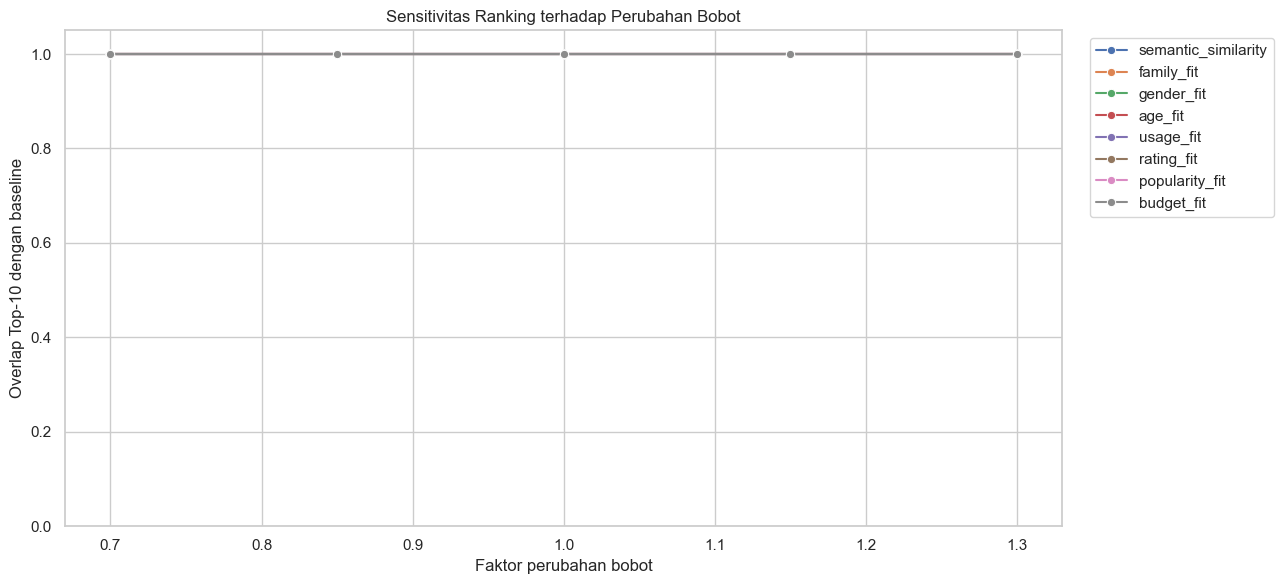

In [65]:
plt.figure(figsize=(13, 6))
sns.lineplot(
    data=sensitivity_df,
    x="factor",
    y="top_n_overlap",
    hue="criterion",
    marker="o",
)
plt.title("Sensitivitas Ranking terhadap Perubahan Bobot")
plt.xlabel("Faktor perubahan bobot")
plt.ylabel("Overlap Top-10 dengan baseline")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 14. Simpan Artifact dan Ringkasan Evaluasi

In [66]:
clean_export = df.drop(columns=["note_terms"]).copy()
clean_export_path = EXPERIMENT_DIR / "prepared_perfume_dataset.csv"
demo_recommendation_path = EXPERIMENT_DIR / "demo_recommendations.csv"
val_prediction_path = EXPERIMENT_DIR / "validation_pair_predictions.csv"
retrieval_metric_path = EXPERIMENT_DIR / "retrieval_metrics.csv"
scenario_metric_path = EXPERIMENT_DIR / "scenario_metrics.csv"
summary_path = EXPERIMENT_DIR / "experiment_summary.json"

clean_export.to_csv(clean_export_path, index=False)
demo_recommendations.to_csv(demo_recommendation_path, index=False)
val_pair_predictions.to_csv(val_prediction_path, index=False)
retrieval_metrics_df.to_csv(retrieval_metric_path, index=False)
scenario_eval_df.to_csv(scenario_metric_path, index=False)

summary = {
    "dataset_path": str(DATASET_PATH),
    "rows_raw": int(len(df_raw)),
    "rows_clean": int(len(df)),
    "base_model": BASE_MODEL_NAME,
    "fine_tuned_model_dir": str(FINE_TUNED_MODEL_DIR) if FINE_TUNED_MODEL_DIR.exists() else None,
    "pair_validation_metrics": pair_metrics,
    "retrieval_metrics": retrieval_metrics_df.to_dict(orient="records"),
    "scenario_metrics": scenario_eval_df.to_dict(orient="records"),
    "default_weights": normalize_weights(DEFAULT_WEIGHTS),
    "artifacts": {
        "prepared_dataset": str(clean_export_path),
        "embeddings": str(embeddings_path),
        "demo_recommendations": str(demo_recommendation_path),
        "validation_pair_predictions": str(val_prediction_path),
        "retrieval_metrics": str(retrieval_metric_path),
        "scenario_metrics": str(scenario_metric_path),
    },
}

with open(summary_path, "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)

print("Ringkasan eksperimen disimpan ke:", summary_path)
print("Artifact eksperimen tersimpan di:", EXPERIMENT_DIR)

Ringkasan eksperimen disimpan ke: f:\perkuliahan\Semester 6\SPK\project\parfum\Perfumes_Recommender-main\reports\sbert_fuzzy_topsis\experiment_summary.json
Artifact eksperimen tersimpan di: f:\perkuliahan\Semester 6\SPK\project\parfum\Perfumes_Recommender-main\reports\sbert_fuzzy_topsis


## 15. Catatan Interpretasi

Hal yang perlu diperhatikan ketika membaca hasil:

- Training loss dan validation loss mengukur kemampuan model mengikuti pseudo-label, bukan preferensi user nyata.
- Pearson/Spearman tinggi berarti ranking similarity model selaras dengan pseudo-label atribut parfum.
- Precision@K/Recall@K memakai relevance berbasis fragrance family dan overlap notes.
- TOPSIS score lebih cocok untuk keputusan rekomendasi akhir karena menggabungkan similarity, family, gender, umur, penggunaan, rating, popularitas, dan budget.
- Jika nanti ada data user asli, bagian pseudo-label sebaiknya diganti atau dikombinasikan dengan label eksplisit dari user.